# Predicting Diabetes from Health and Lifestyle Indicators

This notebook trains and compares Support Vector Machine classifiers (linear, RBF, and polynomial kernels) to predict diabetes status using demographic and lifestyle data from the 2022 National Health Interview Survey (NHIS) via IPUMS Health Surveys.


**Target:** `DIABETICEV` (whether respondent has ever been diagnosed with diabetes)

**Predictors:** BMI, age, physical activity (moderate and vigorous), sleep duration, soda consumption, income-to-poverty ratio, sex

In [3]:
# ====================================================================
# IMPORTS AND DATA LOAD
# ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

# Update path to wherever the NHIS CSV is stored in your Colab session
# The previous error 'ParserError: Error tokenizing data. C error: Expected 48 fields in line 6140, saw 51'
# indicates an issue with malformed lines in the CSV. Using on_bad_lines='skip'
# will tell pandas to ignore these problematic lines.
df = pd.read_csv('nhis_2022.csv', on_bad_lines='skip')

print(f"Raw shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Raw shape: (39665, 48)
Columns: ['YEAR', 'SERIAL', 'STRATA', 'PSU', 'NHISHID', 'REGION', 'PERNUM', 'NHISPID', 'HHX', 'SAMPWEIGHT', 'ASTATFLG', 'CSTATFLG', 'AGE', 'SEX', 'MARSTCUR', 'EDUC', 'HOURSWRK', 'POVERTY', 'HEIGHT', 'WEIGHT', 'BMICALC', 'HINOTCOVE', 'CANCEREV', 'CHEARTDIEV', 'DIABETICEV', 'HEARTATTEV', 'STROKEV', 'ALCANYNO', 'ALCDAYSYR', 'CIGDAYMO', 'MOD10DMIN', 'VIG10DMIN', 'FRUTNO', 'VEGENO', 'JUICEMNO', 'SALADSNO', 'BEANNO', 'SALSAMNO', 'TOMSAUCEMNO', 'SODAPNO', 'FRIESPNO', 'SPORDRMNO', 'FRTDRINKMNO', 'COFETEAMNO', 'POTATONO', 'PIZZANO', 'HRSLEEP', 'CVDSHT']


/tmp/ipykernel_3238/3025535861.py:21: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('nhis_2022.csv', on_bad_lines='skip')


## Data Cleaning

NHIS uses numeric codes for missing/refused/not-in-universe responses (typically 996-999, 97-99). Each variable has its own code conventions, verified against the NHIS 2022 codebook before cleaning.

Cleaning decisions:
- **Adults only**: filter to ages 18-85 (85 is a topcode for "85+")
- **Disease target**: recode `DIABETICEV` from {1=No, 2=Yes} to {0, 1}; drop unknowns
- **Continuous predictors**: replace special codes with NaN, then drop incomplete cases
- **POVERTY**: map ordinal codes to midpoint income-to-poverty ratios for true continuous interpretation
- **SEX**: recode to a binary `MALE` indicator
- **HRSLEEP code 25** ("less than 1 hour") recoded to 0.5 instead of dropped

In [4]:
# ====================================================================
# DATA CLEANING
# ====================================================================

# --- Step 1: Filter to adults with valid age ---
# AGE codes: 85 = "85 or older" (topcode, valid), 997/998/999 = unknowns
df_adult = df[df['AGE'].between(18, 85)].copy()

# --- Step 2: Clean diabetes target ---
# DIABETICEV: 1=No, 2=Yes, 7/9=Unknown
df_adult['diabetes'] = df_adult['DIABETICEV'].where(
    df_adult['DIABETICEV'].isin([1, 2])
).map({1: 0, 2: 1})
df_adult = df_adult.dropna(subset=['diabetes']).copy()
df_adult['diabetes'] = df_adult['diabetes'].astype(int)

# --- Step 3: Replace special codes in predictors with NaN ---
# Codes verified against NHIS 2022 codebook
special_codes = {
    'BMICALC':   [0, 996],                     # 0=NIU, 996=not calculable
    'MOD10DMIN': [996, 997, 998, 999],         # 996=extreme, others=unknown
    'VIG10DMIN': [996, 997, 998, 999],         # same
    'HRSLEEP':   [0, 97, 98, 99],              # 0=NIU, 97-99=unknowns
    'SODAPNO':   [996, 997, 998, 999],         # 996=NIU, others=unknown
    'SEX':       [7, 9],                        # unknowns
}
for col, codes in special_codes.items():
    df_adult[col] = df_adult[col].where(~df_adult[col].isin(codes), np.nan)

# --- Step 4: Variable-specific recodes ---
# HRSLEEP code 25 = "less than 1 hour", treat as 0.5 hours rather than dropping
df_adult['HRSLEEP'] = df_adult['HRSLEEP'].replace(25, 0.5)

# SEX: 1=Male, 2=Female. Convert to binary MALE indicator
df_adult['MALE'] = (df_adult['SEX'] == 1).astype(int)

# POVERTY: map ordinal codes to midpoint income-to-poverty ratios
# Codes from NHIS codebook: 11-14 = under 1.0x, 21-25 = 1.0-1.99x, 31-37 = 2.0-5.0+x
poverty_map = {
    10: 0.5, 11: 0.25, 12: 0.62, 13: 0.87, 14: 0.5,    # under 1.0x poverty
    20: 1.5, 21: 1.12, 22: 1.37, 23: 1.62, 24: 1.87, 25: 1.5,  # 1.0-1.99x
    30: 3.5, 31: 2.25, 32: 2.75, 33: 3.25, 34: 3.75,   # 2.0+x
    35: 4.25, 36: 4.75, 37: 5.0, 38: 3.5,
    98: np.nan, 99: np.nan                              # undefinable, unknown
}
df_adult['POVERTY_RATIO'] = df_adult['POVERTY'].map(poverty_map)

# --- Step 5: Final feature list and complete-case sample ---
predictors = ['BMICALC', 'AGE', 'MOD10DMIN', 'VIG10DMIN',
              'HRSLEEP', 'SODAPNO', 'POVERTY_RATIO', 'MALE']

model_df = df_adult.dropna(subset=predictors + ['diabetes']).copy()

print(f"Modeling sample: {model_df.shape}")
print(f"Diabetes prevalence: {model_df['diabetes'].mean():.1%}")
print(f"\nFeature summary:")
print(model_df[predictors].describe().round(2))

Modeling sample: (27201, 51)
Diabetes prevalence: 10.3%

Feature summary:
        BMICALC       AGE  MOD10DMIN  VIG10DMIN   HRSLEEP   SODAPNO  \
count  27201.00  27201.00   27201.00   27201.00  27201.00  27201.00   
mean      27.96     53.10      43.07      20.67      7.14      1.78   
std        5.54     18.39      59.53      42.46      1.38      4.65   
min       14.80     18.00       0.00       0.00      1.00      0.00   
25%       23.80     37.00       0.00       0.00      6.00      0.00   
50%       27.30     55.00      30.00       0.00      7.00      0.00   
75%       31.20     68.00      60.00      30.00      8.00      2.00   
max       52.70     85.00     720.00     720.00     24.00    240.00   

       POVERTY_RATIO      MALE  
count       27201.00  27201.00  
mean            3.34      0.46  
std             1.58      0.50  
min             0.25      0.00  
25%             1.87      0.00  
50%             3.75      0.00  
75%             5.00      1.00  
max             5.00  

## Exploratory Comparison: Predictors by Diabetes Status

A quick look at how predictors differ between cases and controls. Strong signals from age, BMI, and physical activity. Sleep and sex show essentially no marginal difference. Soda consumption appears slightly lower in diabetics, likely reflecting reverse causation (diet changes after diagnosis), a limitation of cross-sectional data.

Predictor means by diabetes status:
               No diabetes  Diabetes  Difference
BMICALC              27.63     30.81        3.18
AGE                  51.74     65.04       13.30
MOD10DMIN            44.51     30.51      -14.00
VIG10DMIN            21.94      9.50      -12.44
HRSLEEP               7.13      7.18        0.05
SODAPNO               1.82      1.43       -0.39
POVERTY_RATIO         3.39      2.92       -0.47
MALE                  0.46      0.49        0.03


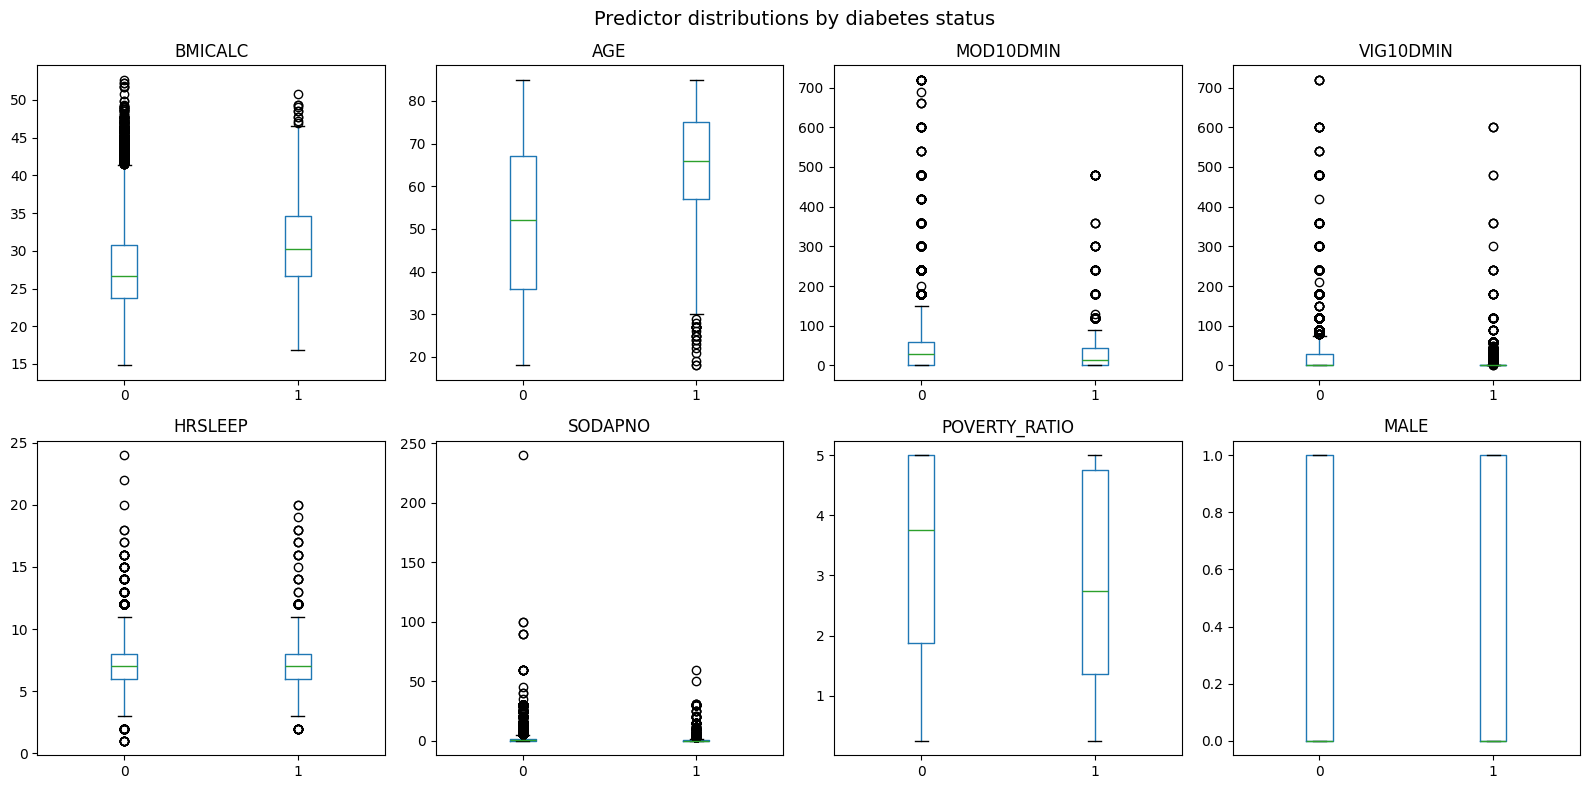

In [5]:
# ====================================================================
# EXPLORATORY DATA ANALYSIS
# ====================================================================
comparison = model_df.groupby('diabetes')[predictors].mean().round(2).T
comparison.columns = ['No diabetes', 'Diabetes']
comparison['Difference'] = comparison['Diabetes'] - comparison['No diabetes']
print("Predictor means by diabetes status:")
print(comparison)

# Boxplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, predictors):
    model_df.boxplot(column=col, by='diabetes', ax=ax, grid=False)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Predictor distributions by diabetes status', fontsize=14)
plt.tight_layout()
plt.savefig('predictor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Train/Test Split and Standardization

80/20 stratified split to preserve the 10.4% diabetes prevalence in both sets. Features are standardized (zero mean, unit variance) using parameters fit on the training set only, then applied to the test set, this prevents test-set information from leaking into the scaling.


In [6]:
# ====================================================================
# TRAIN/TEST SPLIT AND STANDARDIZATION
# ====================================================================
X = model_df[predictors].values
y = model_df['diabetes'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, prevalence: {y_train.mean():.1%}")
print(f"Test:  {X_test_s.shape}, prevalence: {y_test.mean():.1%}")

Train: (21760, 8), prevalence: 10.3%
Test:  (5441, 8), prevalence: 10.3%


## Model Tuning via Cross-Validation

Three SVM kernels are tuned via 3-fold cross-validation on the training set, with ROC-AUC as the scoring metric (preferred over accuracy at this prevalence level, where predicting "no diabetes" for everyone would yield 90% accuracy with zero clinical value).

`class_weight='balanced'` automatically reweights the loss function to compensate for the 10:1 class imbalance, encouraging the model to learn meaningful patterns for the minority class rather than defaulting to majority-class prediction.

**A note on the C parameter:** scikit-learn's C parameter is the inverse of the "C as budget for margin violations" formulation common in textbooks (including ISLR2). In sklearn, larger C means a stronger misclassification penalty and a narrower margin.

In [7]:
# ====================================================================
# MODEL TUNING (3-fold CV, scoring = ROC-AUC)
# ====================================================================

# --- Linear kernel ---
print("Tuning linear SVM...")
start = time.time()
linear_search = GridSearchCV(
    SVC(kernel='linear', class_weight='balanced', random_state=42),
    param_grid={'C': [0.1, 1, 10]},
    cv=3, scoring='roc_auc', n_jobs=-1
)
linear_search.fit(X_train_s, y_train)
print(f"  Best C: {linear_search.best_params_['C']}, "
      f"CV AUC: {linear_search.best_score_:.4f}, "
      f"Time: {time.time() - start:.1f}s")

# --- RBF kernel ---
print("\nTuning RBF SVM...")
start = time.time()
rbf_search = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=42),
    param_grid={'C': [0.5, 1, 2], 'gamma': [0.005, 0.01, 0.02]},
    cv=3, scoring='roc_auc', n_jobs=-1
)
rbf_search.fit(X_train_s, y_train)
print(f"  Best params: {rbf_search.best_params_}, "
      f"CV AUC: {rbf_search.best_score_:.4f}, "
      f"Time: {time.time() - start:.1f}s")

# --- Polynomial kernel ---
print("\nTuning polynomial SVM...")
start = time.time()
poly_search = GridSearchCV(
    SVC(kernel='poly', class_weight='balanced', coef0=1, random_state=42),
    param_grid={'C': [0.1, 1, 10], 'degree': [2, 3], 'gamma': ['scale', 0.01]},
    cv=3, scoring='roc_auc', n_jobs=-1
)
poly_search.fit(X_train_s, y_train)
print(f"  Best params: {poly_search.best_params_}, "
      f"CV AUC: {poly_search.best_score_:.4f}, "
      f"Time: {time.time() - start:.1f}s")

Tuning linear SVM...
  Best C: 0.1, CV AUC: 0.7765, Time: 73.6s

Tuning RBF SVM...
  Best params: {'C': 2, 'gamma': 0.01}, CV AUC: 0.7857, Time: 184.6s

Tuning polynomial SVM...
  Best params: {'C': 1, 'degree': 3, 'gamma': 0.01}, CV AUC: 0.7855, Time: 214.0s


## Test-Set Evaluation

The tuned models are evaluated on the held-out test set. ROC curves and AUC values measure ranking performance independent of any specific decision threshold; classification reports show precision/recall at the default 0.5 threshold (which, with `class_weight='balanced'`, favors recall on the minority class, appropriate for a screening application).


=== Linear kernel ===
Test AUC: 0.7900
              precision    recall  f1-score   support

 No diabetes       0.97      0.64      0.77      4881
    Diabetes       0.20      0.81      0.32       560

    accuracy                           0.65      5441
   macro avg       0.58      0.72      0.54      5441
weighted avg       0.89      0.65      0.72      5441


=== RBF kernel ===
Test AUC: 0.8039
              precision    recall  f1-score   support

 No diabetes       0.97      0.61      0.75      4881
    Diabetes       0.20      0.84      0.32       560

    accuracy                           0.64      5441
   macro avg       0.59      0.73      0.54      5441
weighted avg       0.89      0.64      0.71      5441


=== Polynomial kernel ===
Test AUC: 0.8028
              precision    recall  f1-score   support

 No diabetes       0.97      0.62      0.75      4881
    Diabetes       0.20      0.85      0.33       560

    accuracy                           0.64      5441
   macr

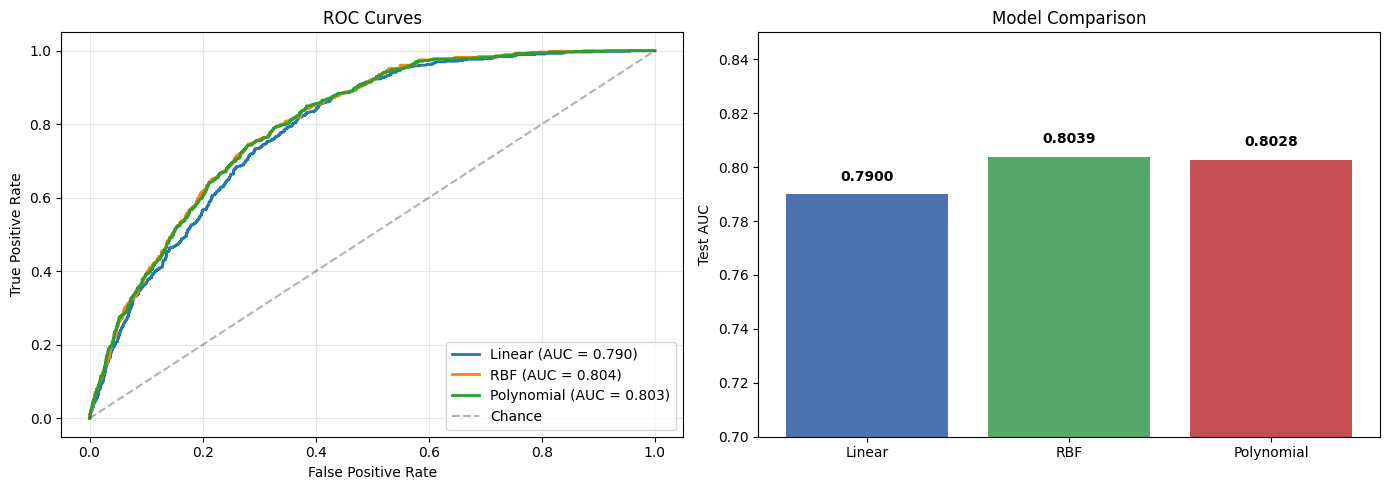

In [8]:
# ====================================================================
# FINAL EVALUATION ON TEST SET
# ====================================================================

# Refit with probability=True for ROC curves
final_models = {
    'Linear': SVC(kernel='linear', C=linear_search.best_params_['C'],
                  class_weight='balanced', probability=True, random_state=42),
    'RBF': SVC(kernel='rbf', C=rbf_search.best_params_['C'],
               gamma=rbf_search.best_params_['gamma'],
               class_weight='balanced', probability=True, random_state=42),
    'Polynomial': SVC(kernel='poly', C=poly_search.best_params_['C'],
                      degree=poly_search.best_params_['degree'],
                      gamma=poly_search.best_params_['gamma'], coef0=1,
                      class_weight='balanced', probability=True, random_state=42),
}

results = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, model in final_models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    results[name] = auc

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

    print(f"\n=== {name} kernel ===")
    print(f"Test AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred,
                                target_names=['No diabetes', 'Diabetes']))

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Chance')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

axes[1].bar(list(results.keys()), list(results.values()),
            color=['#4C72B0', '#55A868', '#C44E52'])
axes[1].set_ylabel('Test AUC')
axes[1].set_title('Model Comparison')
axes[1].set_ylim([0.7, 0.85])
for i, (name, auc) in enumerate(results.items()):
    axes[1].text(i, auc + 0.005, f'{auc:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Expanded Model Comparison

The single AUC values above tell only part of the story under heavy class imbalance. Below I compare the three kernels on additional metrics: Average Precision (area under the PR curve), per-class precision and recall, F1, and the number of support vectors as a model-complexity indicator. Confusion matrices and precision-recall curves complement the metrics table.

EXPANDED MODEL COMPARISON
    Kernel    AUC  Avg Precision  Precision (Diab.)  Recall (Diab.)  F1 (Diab.)  N support vectors % of train
    Linear 0.7900         0.2684              0.202           0.805       0.323              14422      66.3%
       RBF 0.8039         0.2945              0.200           0.843       0.323              14050      64.6%
Polynomial 0.8028         0.2914              0.202           0.850       0.327              14113      64.9%


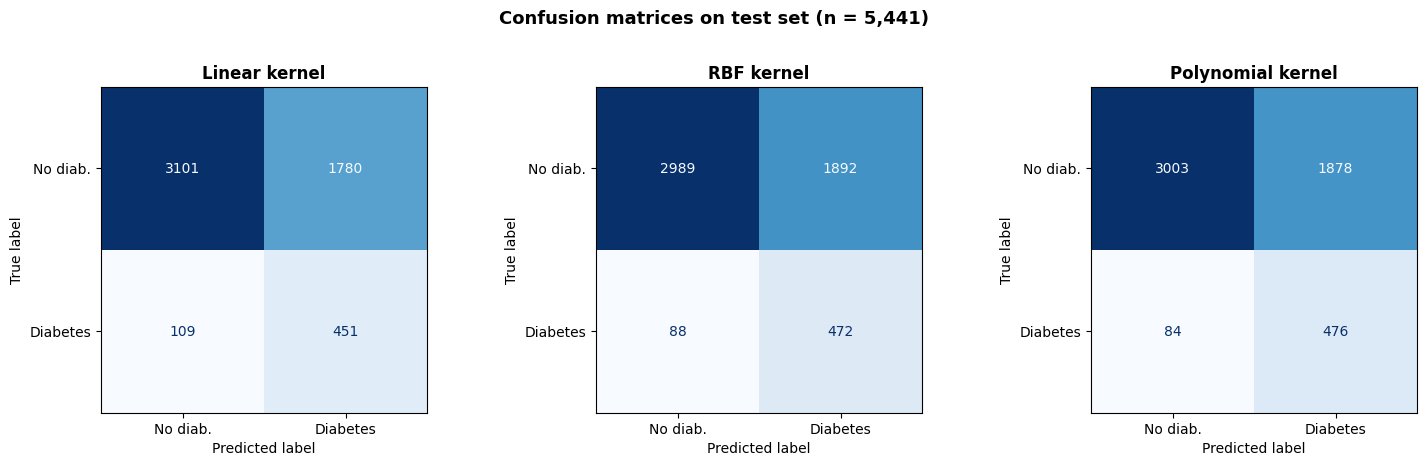

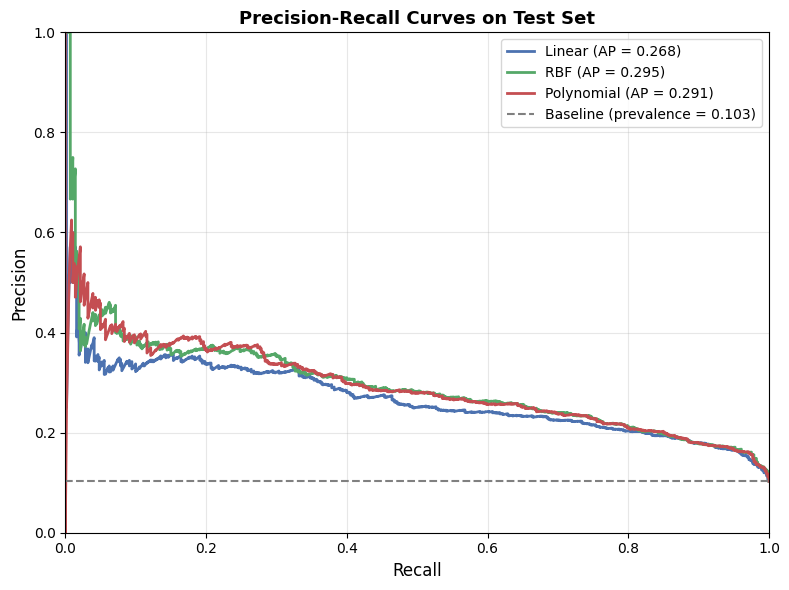

In [9]:
# ====================================================================
# EXPANDED MODEL COMPARISON
# Beyond AUC: per-class metrics, support vector counts, confusion
# matrices, and precision-recall curves.
# ====================================================================
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)

# ---- 1. Comprehensive metrics table ----
rows = []
for name, model in final_models.items():
    y_pred  = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]
    n_sv    = int(model.n_support_.sum())
    rows.append({
        'Kernel':            name,
        'AUC':               round(roc_auc_score(y_test, y_proba), 4),
        'Avg Precision':     round(average_precision_score(y_test, y_proba), 4),
        'Precision (Diab.)': round(precision_score(y_test, y_pred), 3),
        'Recall (Diab.)':    round(recall_score(y_test, y_pred), 3),
        'F1 (Diab.)':        round(f1_score(y_test, y_pred), 3),
        'N support vectors': n_sv,
        '% of train':        f"{100 * n_sv / len(X_train_s):.1f}%",
    })
metrics_df = pd.DataFrame(rows)
print("=" * 80)
print("EXPANDED MODEL COMPARISON")
print("=" * 80)
print(metrics_df.to_string(index=False))

# ---- 2. Confusion matrices, side by side ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, model) in zip(axes, final_models.items()):
    y_pred = model.predict(X_test_s)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['No diab.', 'Diabetes'],
        ax=ax, cmap='Blues', colorbar=False, values_format='d'
    )
    ax.set_title(f'{name} kernel', fontweight='bold')
    ax.grid(False)
plt.suptitle(f'Confusion matrices on test set (n = {len(y_test):,})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()

# ---- 3. Precision-Recall curves ----
# More informative than ROC under heavy class imbalance.
fig, ax = plt.subplots(figsize=(8, 6))
colors = {'Linear': '#4C72B0', 'RBF': '#55A868', 'Polynomial': '#C44E52'}
for name, model in final_models.items():
    y_proba = model.predict_proba(X_test_s)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(rec, prec, color=colors[name], lw=2,
            label=f'{name} (AP = {ap:.3f})')

baseline = y_test.mean()
ax.axhline(baseline, ls='--', color='grey',
           label=f'Baseline (prevalence = {baseline:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves on Test Set',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=200, bbox_inches='tight')
plt.show()

### Interpretation

Looking beyond AUC, the three kernels remain essentially tied:

- **AUC** 0.79–0.80 across all three (within 0.015 of each other)
- **Average Precision** 0.27–0.30 — roughly 3× the no-skill baseline of 0.103, confirming the models learn real signal beyond chance even under 10:1 imbalance
- **Precision** (~0.20) and **recall** (0.81–0.85) are nearly identical across kernels, indicating the same operating point with `class_weight='balanced'`

The high-recall, low-precision profile is the desired behavior for a screening tool: catch ~80–85% of true diabetics at the cost of flagging ~37% of non-diabetics for a follow-up lab test, rather than committing to a diagnosis.

The number of support vectors is unusually high — about **65% of training observations across all three kernels** — meaning most points lie on or near the decision boundary. Combined with the kernel convergence, this points to substantial irreducible noise: the 8 modifiable predictors capture much of the available signal, but overlapping class distributions and the 10:1 imbalance fundamentally limit how cleanly the two groups can be separated.

## Decision Boundary Visualization

To visualize how each kernel partitions the feature space, models are refit using just AGE and BMI, the two strongest individual predictors. The plots show the actual training data colored by class and the decision boundary each kernel learns. The linear kernel produces a single straight cut; RBF and polynomial kernels produce smooth curved boundaries that capture interactions between age and BMI.

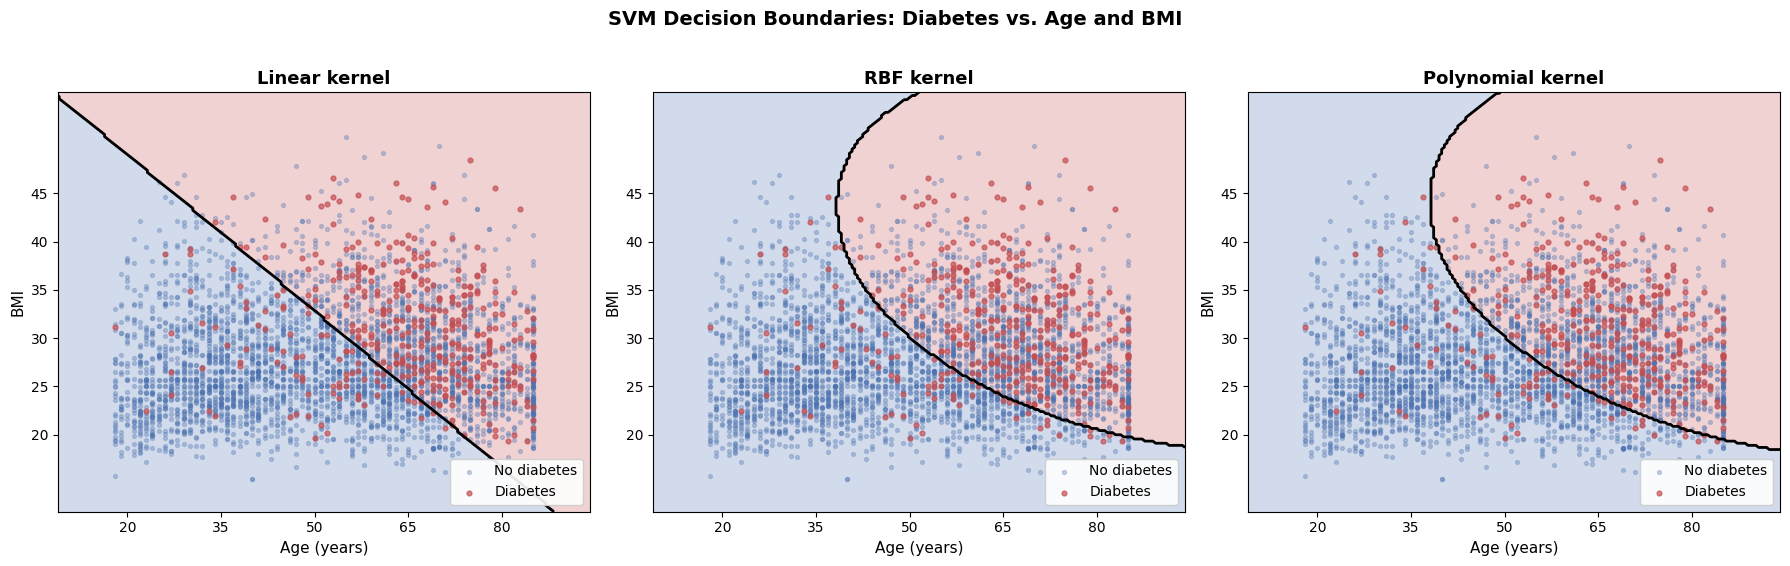

In [10]:
# ====================================================================
# DECISION BOUNDARY VISUALIZATION (2 strongest predictors)
# ====================================================================
viz_features = ['AGE', 'BMICALC']
X_viz = model_df[viz_features].values
y_viz = model_df['diabetes'].values

X_viz_train, X_viz_test, y_viz_train, y_viz_test = train_test_split(
    X_viz, y_viz, test_size=0.2, stratify=y_viz, random_state=42
)

scaler_viz = StandardScaler()
X_viz_train_s = scaler_viz.fit_transform(X_viz_train)

viz_models = {
    'Linear': SVC(kernel='linear', C=1, class_weight='balanced', random_state=42),
    'RBF': SVC(kernel='rbf', C=1, gamma=0.01, class_weight='balanced', random_state=42),
    'Polynomial': SVC(kernel='poly', C=1, degree=3, gamma=0.01, coef0=1,
                      class_weight='balanced', random_state=42)
}

# Grid for contour plotting
x_min, x_max = X_viz_train_s[:, 0].min() - 0.5, X_viz_train_s[:, 0].max() + 0.5
y_min, y_max = X_viz_train_s[:, 1].min() - 0.5, X_viz_train_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Subsample for plot legibility
np.random.seed(42)
idx = np.random.choice(len(X_viz_train_s), size=4000, replace=False)
X_plot = X_viz_train_s[idx]
y_plot = y_viz_train[idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (name, model) in zip(axes, viz_models.items()):
    model.fit(X_viz_train_s, y_viz_train)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap=ListedColormap(['#4C72B0', '#C44E52']))
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

    ax.scatter(X_plot[y_plot == 0, 0], X_plot[y_plot == 0, 1],
               c='#4C72B0', s=8, alpha=0.3, label='No diabetes')
    ax.scatter(X_plot[y_plot == 1, 0], X_plot[y_plot == 1, 1],
               c='#C44E52', s=12, alpha=0.7, label='Diabetes')

    age_ticks = scaler_viz.transform([[a, 30] for a in [20, 35, 50, 65, 80]])[:, 0]
    bmi_ticks = scaler_viz.transform([[50, b] for b in [20, 25, 30, 35, 40, 45]])[:, 1]
    ax.set_xticks(age_ticks); ax.set_xticklabels([20, 35, 50, 65, 80])
    ax.set_yticks(bmi_ticks); ax.set_yticklabels([20, 25, 30, 35, 40, 45])

    ax.set_xlabel('Age (years)', fontsize=11)
    ax.set_ylabel('BMI', fontsize=11)
    ax.set_title(f'{name} kernel', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', framealpha=0.9)

plt.suptitle('SVM Decision Boundaries: Diabetes vs. Age and BMI',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=200, bbox_inches='tight')
plt.show()

## Summary

Three SVM kernels (linear, RBF, polynomial) were trained to classify diabetes status from NHIS 2022 demographic and lifestyle data. All three achieved closely matched performance on the held-out test set (AUC 0.79–0.80, AP 0.27–0.30), with no kernel meaningfully outperforming the others. The convergence indicates the underlying decision surface is well-captured by smooth, near-linear functions in the 8-feature predictor space; flexible kernels offer no additional discriminative power.

Each model captures 80–85% of true diabetics (recall) while flagging ~37% of non-diabetics (precision ~20%), an appropriate profile for population-level screening. Roughly 65% of training observations serve as support vectors across all three kernels — an unusually high fraction reflecting overlapping class distributions, modest predictor signal, and the 10:1 class imbalance.

Given equivalent performance across kernels, the **linear SVM is the recommended model**: comparable test AUC and AP to the kernelized alternatives, simpler to interpret, and faster at prediction time. AGE and BMI act as the joint risk axes visible in the decision-boundary plots; physical activity provides additional signal. Sleep, sex, and household income contributed little marginal value.

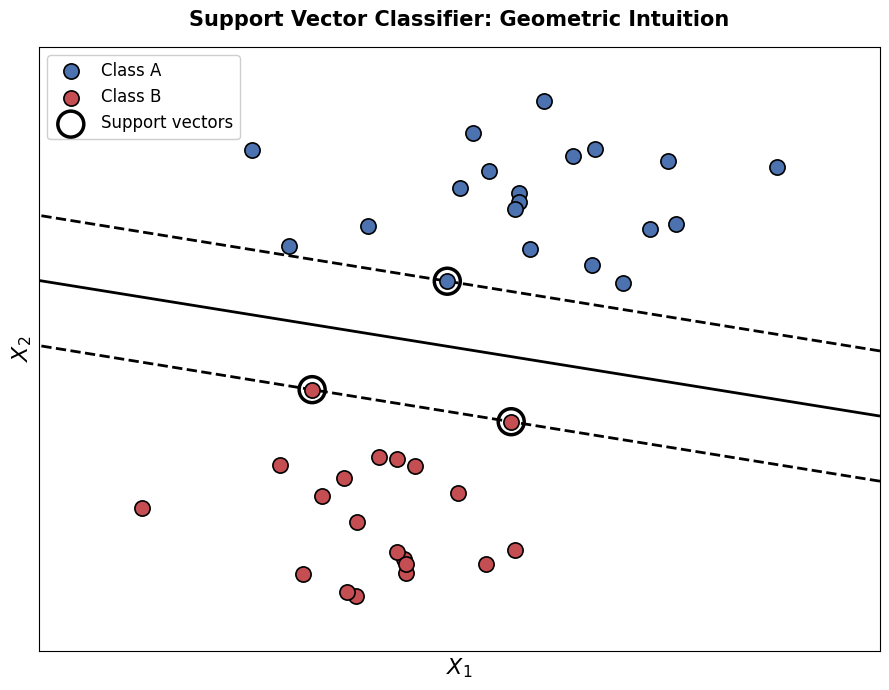

In [11]:
# ====================================================================
# CONCEPTUAL SVM DIAGRAM FOR POSTER
# ====================================================================
# Synthetic 2-class data with a clean linear separator, used to
# illustrate hyperplane, margin, and support vectors visually.

from sklearn.datasets import make_blobs

# Generate two well-separated clusters
X_demo, y_demo = make_blobs(n_samples=40, centers=2, n_features=2,
                             cluster_std=1.0, random_state=6)

# Fit a linear SVC (no class weighting needed, balanced synthetic data)
demo_svc = SVC(kernel='linear', C=10).fit(X_demo, y_demo)

# Build a fine grid for plotting the decision function
xx_d, yy_d = np.meshgrid(
    np.linspace(X_demo[:, 0].min() - 1, X_demo[:, 0].max() + 1, 300),
    np.linspace(X_demo[:, 1].min() - 1, X_demo[:, 1].max() + 1, 300)
)
Z_demo = demo_svc.decision_function(np.c_[xx_d.ravel(), yy_d.ravel()]).reshape(xx_d.shape)

# Identify support vectors
sv = demo_svc.support_vectors_

fig, ax = plt.subplots(figsize=(9, 7))

# Plot data points (no diabetes color = blue, diabetes color = red,
# matching the rest of the poster's color scheme)
ax.scatter(X_demo[y_demo == 0, 0], X_demo[y_demo == 0, 1],
           c='#4C72B0', s=120, edgecolor='black', linewidth=1.2,
           label='Class A', zorder=3)
ax.scatter(X_demo[y_demo == 1, 0], X_demo[y_demo == 1, 1],
           c='#C44E52', s=120, edgecolor='black', linewidth=1.2,
           label='Class B', zorder=3)

# Highlight support vectors with a larger ring
ax.scatter(sv[:, 0], sv[:, 1], s=350, facecolors='none',
           edgecolors='black', linewidth=2.5, zorder=2,
           label='Support vectors')

# Draw the hyperplane (decision boundary, level=0) and margins (±1)
ax.contour(xx_d, yy_d, Z_demo, levels=[-1, 0, 1],
           colors='black', linestyles=['--', '-', '--'], linewidths=2)

# Annotations: hyperplane label, margin labels
ax.annotate('Hyperplane\n(decision boundary)',
            xy=(0.5, 0.5), xytext=(4, 5),
            fontsize=14, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax.annotate('Margin (M)',
            xy=(2, 2), xytext=(6, 0),
            fontsize=14, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax.set_xlabel('$X_1$', fontsize=16)
ax.set_ylabel('$X_2$', fontsize=16)
ax.set_title('Support Vector Classifier: Geometric Intuition',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=12, framealpha=0.95)
ax.grid(alpha=0.2)

# Hide tick labels since the values aren't meaningful here
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.savefig('svm_concept_diagram.png', dpi=200, bbox_inches='tight')
plt.show()